In [27]:
%load_ext mypy_ipython

The mypy_ipython extension is already loaded. To reload it, use:
  %reload_ext mypy_ipython


In [28]:
from langgraph.graph import START, END, StateGraph, add_messages
from typing_extensions import TypedDict
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence
from typing import Literal, Annotated

# The Annotated Construct and Reducer Function

## Using add_messages Function

In [29]:
my_list = add_messages()

## Define State

In [30]:
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

## Define Nodes

In [31]:
chat = ChatOllama( model= 'llama3.2',seed=365, temperature=0, num_predict=256)

In [32]:
def ask_question(state: State) -> State:
     print(f"\n --------> ENTERING ask_question:")
     for i in state['messages']:
        i.pretty_print()
        
     question = "What is your question?"

     return State(messages = [AIMessage(question) ,HumanMessage(input())])

In [33]:
def ask_another_question(state: State) -> State:
     print(f"\n --------> ENTERING ask_another_question:")
     for i in state['messages']:
        i.pretty_print()
     question = "Would you like to ask one more question (yes/no)?"
     return State(messages = [AIMessage(question) ,HumanMessage(input())])

In [34]:
def chatbot(state: State) -> State:

    print(f"\n --------> ENTERING chatbot:")
    for i in state['messages']:
        i.pretty_print()
    response = chat.invoke(state['messages'])
    response.pretty_print()
    return State(messages = [response])

### Routing Function

In [35]:
def routing_function(state: State) -> Literal['ask_question', "__end__"]:
    if state['messages'][-1].content == 'yes':
        return 'ask_question'
    else:
        return "__end__"

### Define Graph

In [36]:
graph = StateGraph(State)

In [37]:
graph.add_node('ask_question', ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node('ask_another_question', ask_another_question)


graph.add_edge(START, "ask_question")
graph.add_edge('ask_question', "chatbot")
graph.add_edge('chatbot', 'ask_another_question')
graph.add_conditional_edges(source='ask_another_question', path=routing_function)

In [38]:
graph_compiled = graph.compile()

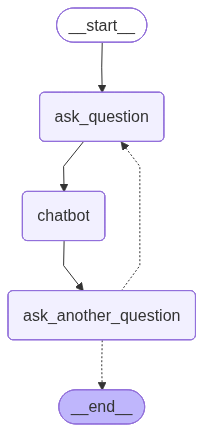

In [39]:
graph_compiled

In [40]:
graph_compiled.invoke(State(messages = []))


 --------> ENTERING ask_question:


 What is the best car brand now days?



 --------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What is the best car brand now days?
================================== Ai Message ==================================

Determining the "best" car brand can be subjective and depends on various factors such as personal preferences, budget, and specific needs (e.g., family, performance, fuel efficiency). That being said, here are some of the top-rated car brands in different categories:

**Overall Quality and Reliability:**

1. Lexus - Known for their luxurious and reliable vehicles.
2. Toyota - Offers a wide range of models with excellent reliability and durability.
3. Porsche - Renowned for their high-performance and premium vehicles.

**Luxury:**

1. Mercedes-Benz - Offers a wide range of luxury vehicles with advanced features.
2. BMW - Provides high-performance and styli

 yes



 --------> ENTERING ask_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What is the best car brand now days?
================================== Ai Message ==================================

Determining the "best" car brand can be subjective and depends on various factors such as personal preferences, budget, and specific needs (e.g., family, performance, fuel efficiency). That being said, here are some of the top-rated car brands in different categories:

**Overall Quality and Reliability:**

1. Lexus - Known for their luxurious and reliable vehicles.
2. Toyota - Offers a wide range of models with excellent reliability and durability.
3. Porsche - Renowned for their high-performance and premium vehicles.

**Luxury:**

1. Mercedes-Benz - Offers a wide range of luxury vehicles with advanced features.
2. BMW - Provides high-performance and 

 what was my preveus question



 --------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What is the best car brand now days?
================================== Ai Message ==================================

Determining the "best" car brand can be subjective and depends on various factors such as personal preferences, budget, and specific needs (e.g., family, performance, fuel efficiency). That being said, here are some of the top-rated car brands in different categories:

**Overall Quality and Reliability:**

1. Lexus - Known for their luxurious and reliable vehicles.
2. Toyota - Offers a wide range of models with excellent reliability and durability.
3. Porsche - Renowned for their high-performance and premium vehicles.

**Luxury:**

1. Mercedes-Benz - Offers a wide range of luxury vehicles with advanced features.
2. BMW - Provides high-performance and styli

 no


{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='902c569b-f36c-491a-9082-68565e9f3701'),
  HumanMessage(content='What is the best car brand now days?', additional_kwargs={}, response_metadata={}, id='403fe658-aa36-4cf6-b525-f1c7c2d2f323'),
  AIMessage(content='Determining the "best" car brand can be subjective and depends on various factors such as personal preferences, budget, and specific needs (e.g., family, performance, fuel efficiency). That being said, here are some of the top-rated car brands in different categories:\n\n**Overall Quality and Reliability:**\n\n1. Lexus - Known for their luxurious and reliable vehicles.\n2. Toyota - Offers a wide range of models with excellent reliability and durability.\n3. Porsche - Renowned for their high-performance and premium vehicles.\n\n**Luxury:**\n\n1. Mercedes-Benz - Offers a wide range of luxury vehicles with advanced features.\n2. BMW - Provides high-performance and stylish luxu